First 5 rows of Iris dataset as list of lists:
[[5.1, 3.5, 1.4, 0.2], [4.9, 3.0, 1.4, 0.2], [4.7, 3.2, 1.3, 0.2], [4.6, 3.1, 1.5, 0.2], [5.0, 3.6, 1.4, 0.2]]

Overall Mean and Standard Deviation
sepal length (cm) -> Mean: 5.84, Std Dev: 0.83
sepal width (cm) -> Mean: 3.06, Std Dev: 0.43
petal length (cm) -> Mean: 3.76, Std Dev: 1.76
petal width (cm) -> Mean: 1.20, Std Dev: 0.76

Mean and Standard Deviation by Species

Species: setosa
sepal length (cm) -> Mean: 5.01, Std Dev: 0.35
sepal width (cm) -> Mean: 3.43, Std Dev: 0.38
petal length (cm) -> Mean: 1.46, Std Dev: 0.17
petal width (cm) -> Mean: 0.25, Std Dev: 0.10

Species: versicolor
sepal length (cm) -> Mean: 5.94, Std Dev: 0.51
sepal width (cm) -> Mean: 2.77, Std Dev: 0.31
petal length (cm) -> Mean: 4.26, Std Dev: 0.47
petal width (cm) -> Mean: 1.33, Std Dev: 0.20

Species: virginica
sepal length (cm) -> Mean: 6.59, Std Dev: 0.63
sepal width (cm) -> Mean: 2.97, Std Dev: 0.32
petal length (cm) -> Mean: 5.55, Std Dev: 0.55
petal wid

/tmp/ipykernel_495/607882275.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=feature_names)


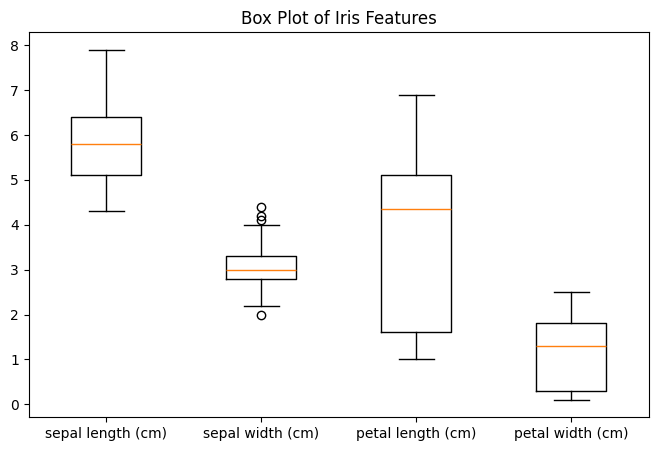

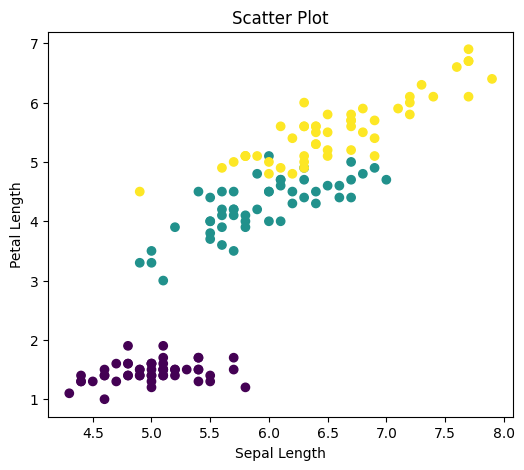

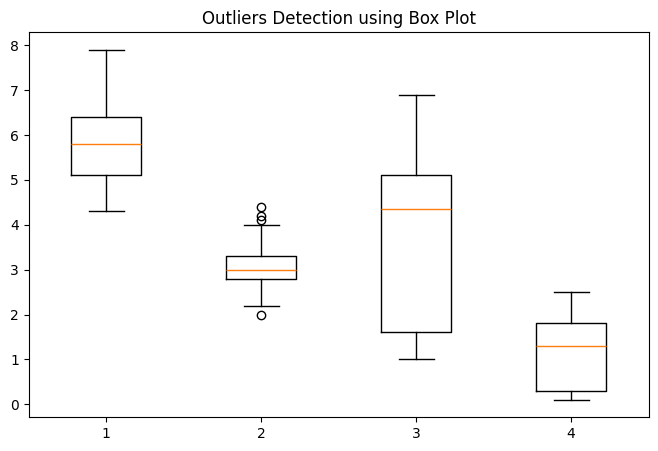

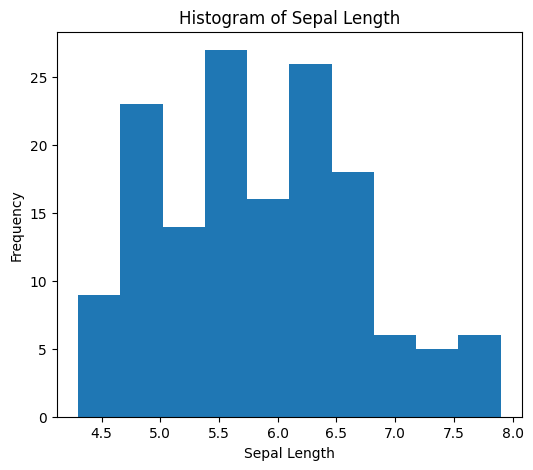

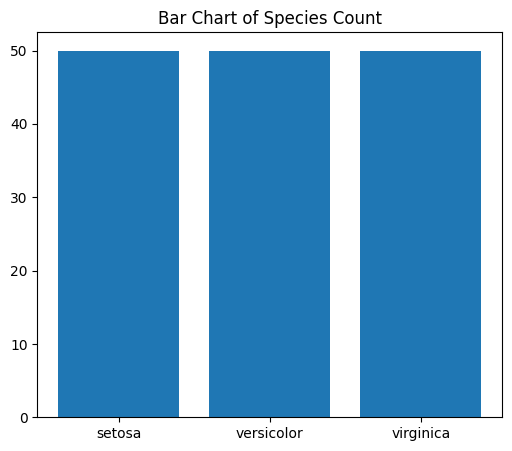

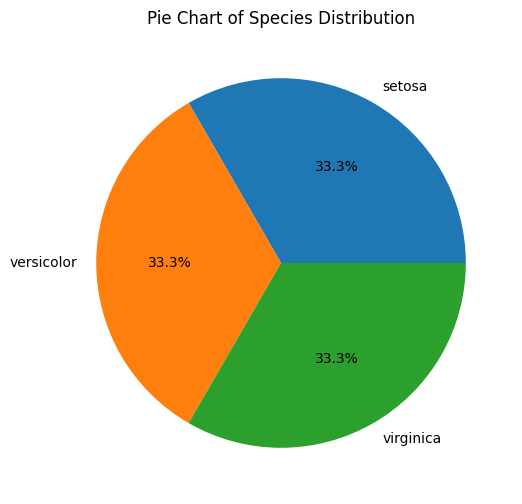

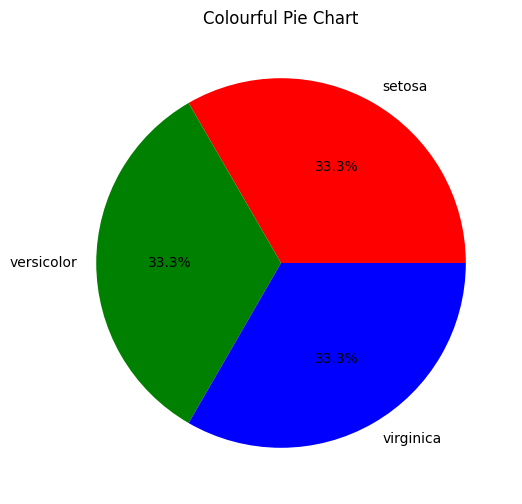

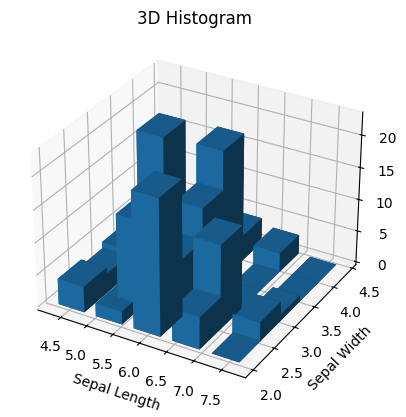

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from mpl_toolkits.mplot3d import Axes3D

# Load Iris dataset
iris = load_iris()

data = iris.data
species = iris.target
feature_names = iris.feature_names
species_names = iris.target_names

# Convert to list of lists
iris_list = data.tolist()

print("First 5 rows of Iris dataset as list of lists:")
print(iris_list[:5])

# Overall Mean and Standard Deviation
print("\nOverall Mean and Standard Deviation")
for i in range(4):
    col = data[:, i]
    print(f"{feature_names[i]} -> Mean: {np.mean(col):.2f}, Std Dev: {np.std(col):.2f}")

# Mean and Std Dev for each species
print("\nMean and Standard Deviation by Species")

for i, name in enumerate(species_names):
    subset = data[species == i]
    print(f"\nSpecies: {name}")

    for j in range(4):
        col = subset[:, j]
        print(f"{feature_names[j]} -> Mean: {np.mean(col):.2f}, Std Dev: {np.std(col):.2f}")

# -------------------------------
# a) Box Plot (Distribution)
# -------------------------------

plt.figure(figsize=(8,5))
plt.boxplot(data, labels=feature_names)
plt.title("Box Plot of Iris Features")
plt.show()

# Scatter Plot

plt.figure(figsize=(6,5))
plt.scatter(data[:,0], data[:,2], c=species)
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Scatter Plot")
plt.show()

# -------------------------------
# b) Outliers using Box Plot
# -------------------------------

plt.figure(figsize=(8,5))
plt.boxplot(data)
plt.title("Outliers Detection using Box Plot")
plt.show()

# -------------------------------
# c) Histogram
# -------------------------------

plt.figure(figsize=(6,5))
plt.hist(data[:,0], bins=10)
plt.title("Histogram of Sepal Length")
plt.xlabel("Sepal Length")
plt.ylabel("Frequency")
plt.show()

# Bar Chart (Species count)

species_count = [np.sum(species==0), np.sum(species==1), np.sum(species==2)]

plt.figure(figsize=(6,5))
plt.bar(species_names, species_count)
plt.title("Bar Chart of Species Count")
plt.show()

# Pie Chart

plt.figure(figsize=(6,6))
plt.pie(species_count, labels=species_names, autopct='%1.1f%%')
plt.title("Pie Chart of Species Distribution")
plt.show()

# -------------------------------
# d) Colourful Pie Chart
# -------------------------------

colors = ['red','green','blue']

plt.figure(figsize=(6,6))
plt.pie(species_count, labels=species_names, colors=colors, autopct='%1.1f%%')
plt.title("Colourful Pie Chart")
plt.show()

# -------------------------------
# 3D Histogram
# -------------------------------

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

hist, xedges, yedges = np.histogram2d(data[:,0], data[:,1], bins=5)

xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1])
xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros_like(xpos)

dx = dy = 0.5
dz = hist.flatten()

ax.bar3d(xpos, ypos, zpos, dx, dy, dz)

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Frequency')

plt.title("3D Histogram")
plt.show()

Coefficient: [1.85843298]
Intercept: -7.101443369602455


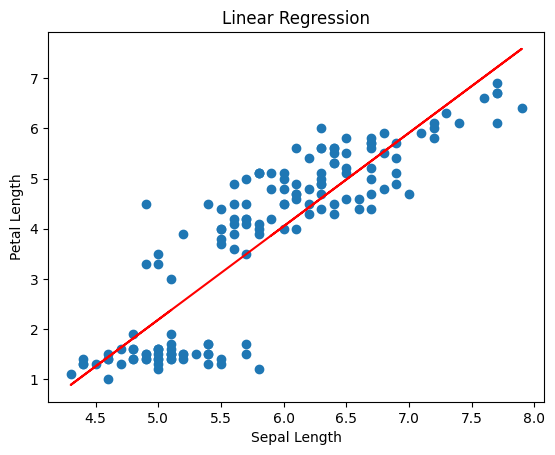

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression

# Load dataset
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Independent and dependent variables
X = df[['sepal length (cm)']]
y = df['petal length (cm)']

# Create Regression Model
model = LinearRegression()
model.fit(X, y)

# Print coefficient and intercept
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

# Plot Regression Line
plt.scatter(X, y)
plt.plot(X, model.predict(X), color='red')
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Linear Regression")
plt.show()

Correlation Matrix:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


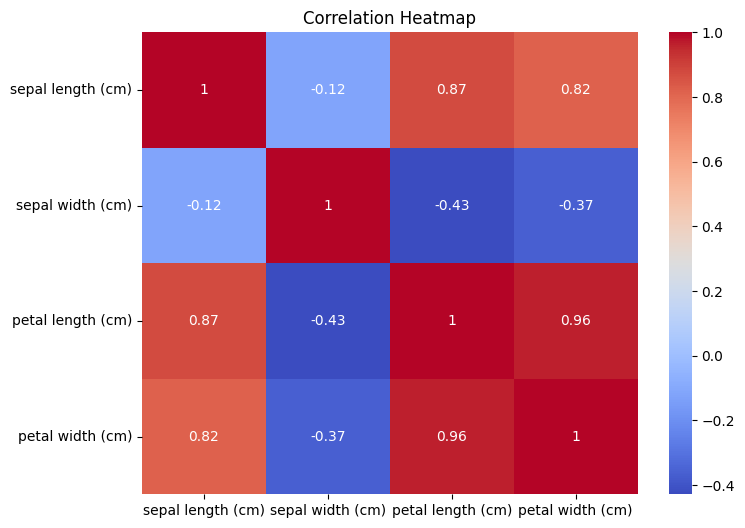


ANOVA Result
F-Statistic: 1180.1611822529785
P-value: 2.8567766109619814e-91


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.stats import f_oneway

# Load dataset
iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# --------------------------
# Correlation Matrix
# --------------------------

corr = df.drop("species", axis=1).corr()

print("Correlation Matrix:")
print(corr)

# --------------------------
# Correlation Plot (Heatmap)
# --------------------------

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# --------------------------
# ANOVA Test
# --------------------------

setosa = df[df['species']==0]['petal length (cm)']
versicolor = df[df['species']==1]['petal length (cm)']
virginica = df[df['species']==2]['petal length (cm)']

anova = f_oneway(setosa, versicolor, virginica)

print("\nANOVA Result")
print("F-Statistic:", anova.statistic)
print("P-value:", anova.pvalue)